#! get data from video with drawings for detections to go with detections.csv file

In [1]:
# import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA


In [2]:

df = pd.read_csv('./dataset/detections-5.csv')

# print(df.shape)
# print(df.head(5))
# print(df.describe())
#* df['x1'] = df['x1'].str.replace(r'\D', '', regex=True) # caught some extra 'n' and 'q' chars from terminal (fix later, what if it was a number instead...)

# print(df.T)


In [41]:
plt.rcParams['figure.figsize'] = (4, 2)

pca = PCA(n_components=1)
df['xy_pca'] = pca.fit_transform(df[['x1','x2','y1', 'y2']])
df['center_x'] = abs(df['x1']-df['x2'])
df['center_y'] = abs(df['y1']-df['y2'])
print(df)
df.columns

       x1   y1   x2   y2  confidence   class_name  tracker_id  recording_name  \
0     428  210  457  241       0.869  hummingbird           1  detect_096.mp4   
1     420  211  446  235       0.825  hummingbird           1  detect_096.mp4   
2     411  214  439  237       0.845  hummingbird           1  detect_096.mp4   
3     413  215  438  239       0.855  hummingbird           1  detect_096.mp4   
4     412  219  441  237       0.491  hummingbird           1  detect_096.mp4   
...   ...  ...  ...  ...         ...          ...         ...             ...   
5716  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5717  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5718  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5719  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5720  410  221  424  242       0.711  hummingbird          56    rec_1206.mp4   

      frame_time  frame_num

Index(['x1', 'y1', 'x2', 'y2', 'confidence', 'class_name', 'tracker_id',
       'recording_name', 'frame_time', 'frame_num', 'xy_pca', 'center_x',
       'center_y'],
      dtype='object')

name: detect_096.mp4


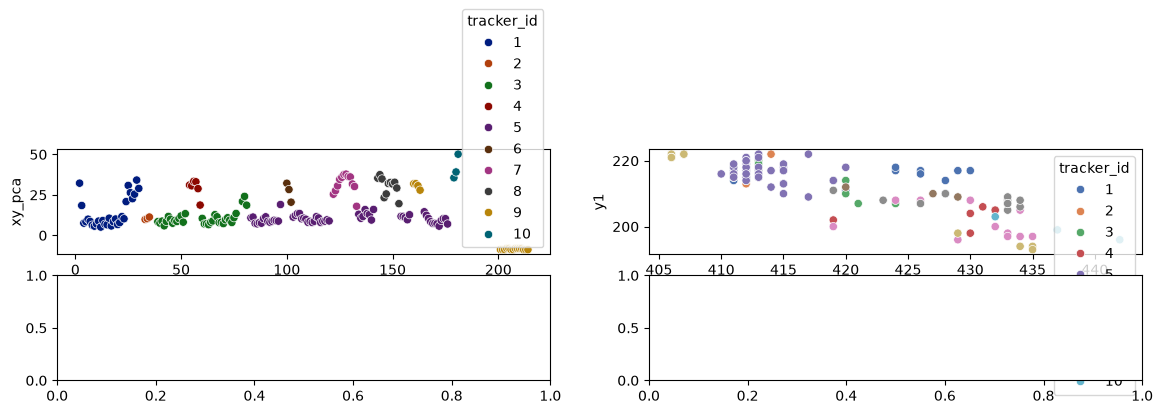

name: detect_097.mp4


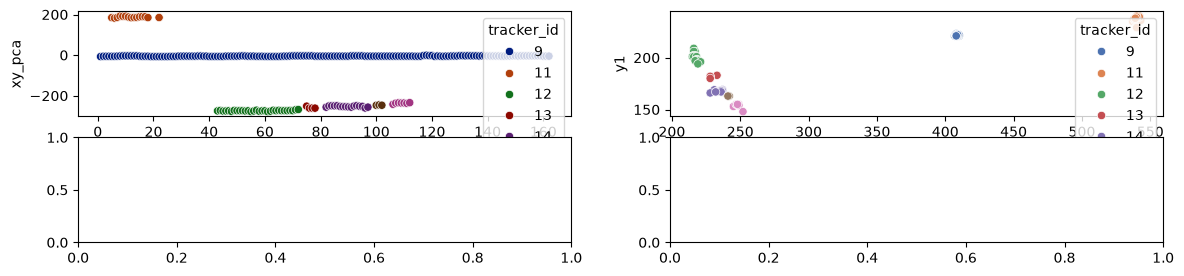

name: detect_098.mp4


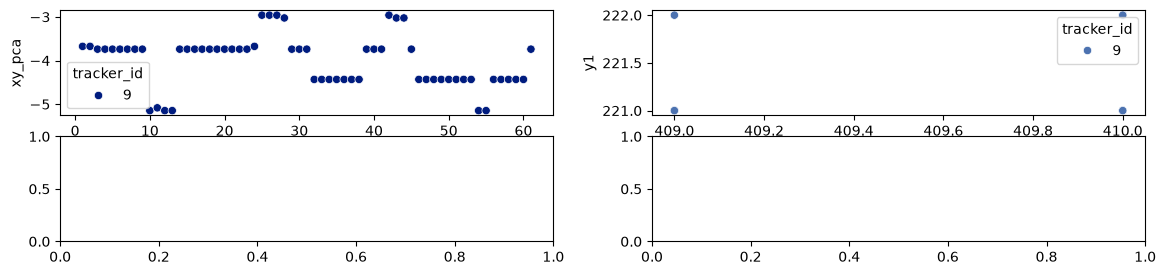

name: detect_108.mp4


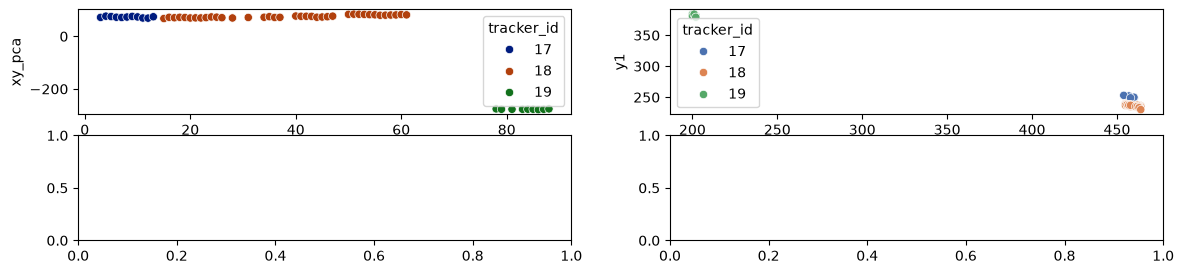

name: detect_109.mp4


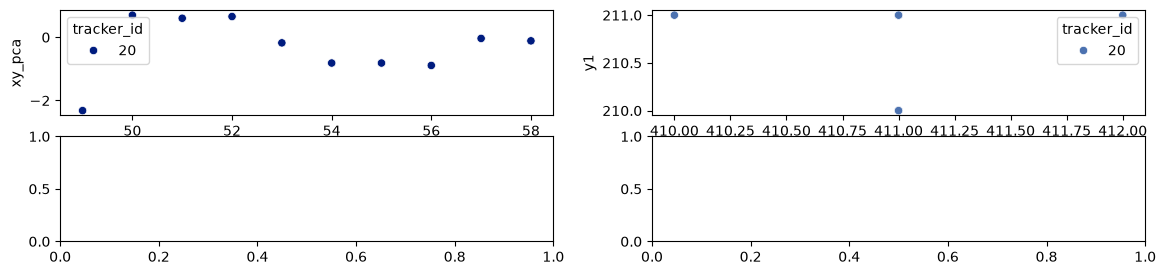

name: detect_112.mp4


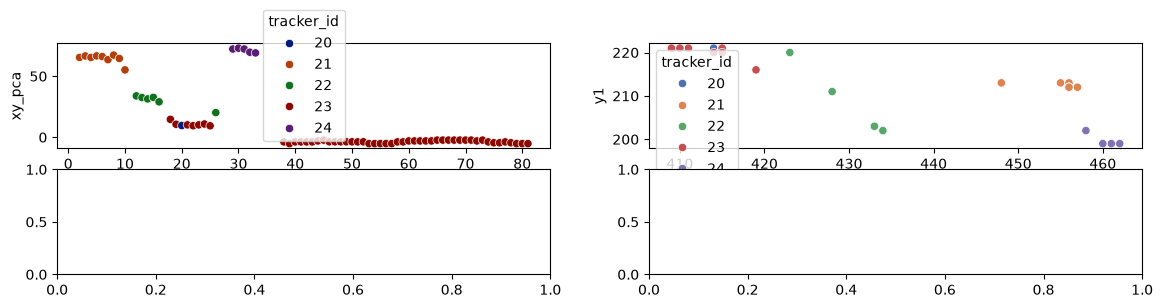

In [37]:

# sns.scatterplot(x=df['x1'], y=df['y1'], hue=df['tracker_id'], palette='Reds')
# plt.show()

# sns.scatterplot(x=pd['frame_num'], y=pd['xy_pca'], hue=pd['tracker_id'], palette='Reds')

# sns.boxplot(x=df['x1'], y=df['y1'])

# sns.lineplot(x=df['x1'], y=df['y1'])
# sns.heatmap(data = df[['x1', 'y1', 'tracker_id']])
# plt.show()
# corr = df.corr(numeric=True)
# sns.heatmap(data=corr, cmap='coolwarm')
# plt.show()


# fig, axes = plt.subplots(3,3, figsize=(10,5))

i = 0
for name, group in df.groupby('recording_name'):
    if i > 5: break
    i+=1
    print(f'name: {name}')
    # plt.figure(figsize=(4,2))
    fig, axes = plt.subplots(2,2, figsize=(14, 3))

    sns.scatterplot(x=group['frame_num'], y=group['xy_pca'], hue=group['tracker_id'], palette='dark', ax=axes[0][0])
    sns.scatterplot(x=group['x1'], y=group['y1'], hue=group['tracker_id'], palette='deep', ax=axes[0][1])

    # print()
    plt.show()


In [53]:

X = df[['x1','x2','y1', 'y2', 'confidence']]
y = df[['tracker_id']]
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

X2 = df[['x1', 'y1', 'x2', 'y2', 'confidence', 'frame_num', 'xy_pca']]
y2 = df[['tracker_id']]
X2_train,X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=.2)

model = KNeighborsClassifier()
model.fit(X_train, y_train)
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(f'train: {train_score:.2f} test: {test_score:.2f} report:\n')

model = KNeighborsClassifier()
model.fit(X2_train, y2_train)
train_score = model.score(X2_train,y2_train)
test_score = model.score(X2_test,y2_test)
print(f'train2: {train_score:.2f} test2: {test_score:.2f} report:\n')


/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


train: 0.91 test: 0.87 report:

train2: 0.98 test2: 0.94 report:



/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [40]:

estimator = KNeighborsClassifier()
param_grid={
    'n_neighbors':(2,4,5,8,10),
    'weights':('uniform', 'distance'),
    'leaf_size':(1,20,30),
    'p':(1,2),
    'metric':('minkowski','chebyshev')
}
# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision',
#     'recall': 'recall',
#     'f1': 'f1',
# }
grid = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    cv=5
)

grid.fit(X_train, y_train)
print('best params',grid.best_params_)
print('best score ',grid.best_score_)

# best_params = {'leaf_size': 1, 'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
best_params = grid.best_params_
model = KNeighborsClassifier(**best_params)
model.fit(X_train,y_train)

train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(f'train: {train_score:.2f} test: {test_score:.2f}')


/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

best params {'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
best score  0.8417820411864365
train: 0.89 test: 0.84
